<a href="https://colab.research.google.com/github/Dice128/2025_VISIKOMPUTER_TI-2B/blob/main/Praktikum%2003%20Teknik%20Regresi%20Gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Langkah Pengerjaan
## Praktikum D1 – Regresi dari Citra Sintetis (Prediksi Radius Lingkaran)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models

# Generator 1 sample
def make_sample(img_size=64, min_r=5, max_r=20):
    r = np.random.randint(min_r, max_r + 1)  # radius acak
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    cx = np.random.randint(r, img_size - r)  # center-x
    cy = np.random.randint(r, img_size - r)  # center-y
    cv2.circle(img, (cx, cy), r, (255,), -1)  # lingkaran putih terisi
    img = (img / 255.0).astype(np.float32)
    # 3-channel biar kompatibel CNN
    img3 = np.stack([img, img, img], axis=-1)
    return img3, float(r), (cx, cy)

### Tugas Kecil

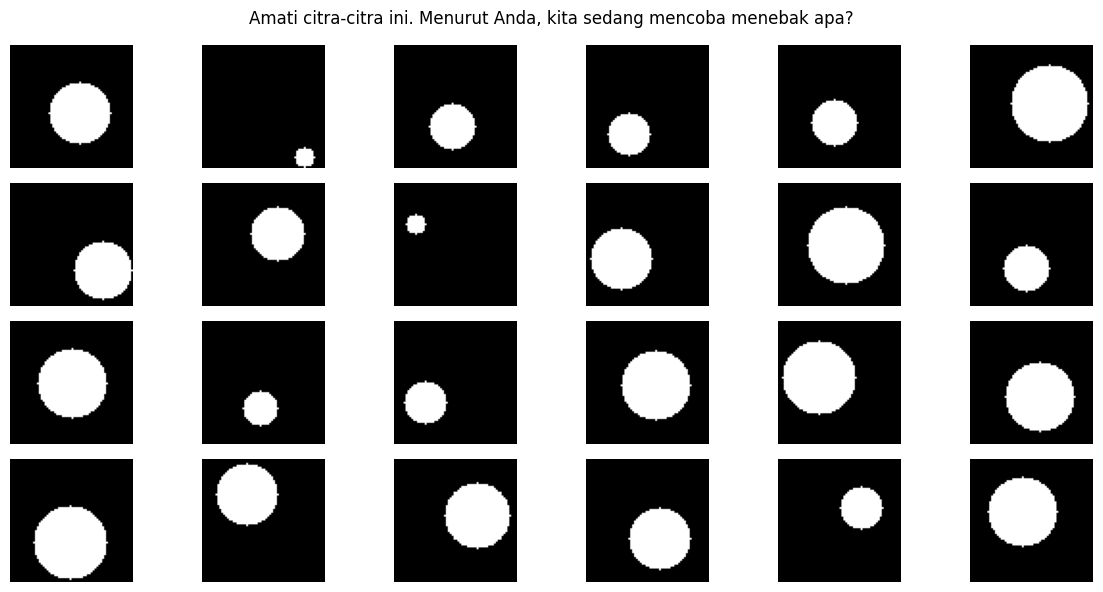

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Pastikan fungsi ini sudah didefinisikan dari kode sebelumnya
def make_sample(img_size=64, min_r=5, max_r=20):
    r = np.random.randint(min_r, max_r + 1)
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    cx = np.random.randint(r, img_size - r)
    cy = np.random.randint(r, img_size - r)
    cv2.circle(img, (cx, cy), r, (255,), -1)
    img = (img / 255.0).astype(np.float32)
    img3 = np.stack([img, img, img], axis=-1)
    return img3, float(r), (cx, cy)

# Buat 24 contoh untuk visualisasi
N_show = 24
samples = [make_sample() for _ in range(N_show)]
imgs = [s[0] for s in samples]
rads = [s[1] for s in samples]
centers = [s[2] for s in samples]

# Grid gambar tanpa label:
cols = 6
rows = N_show // cols
plt.figure(figsize=(12, 6))
for i in range(N_show):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Amati citra-citra ini. Menurut Anda, kita sedang mencoba menebak apa?")
plt.tight_layout()
plt.show()

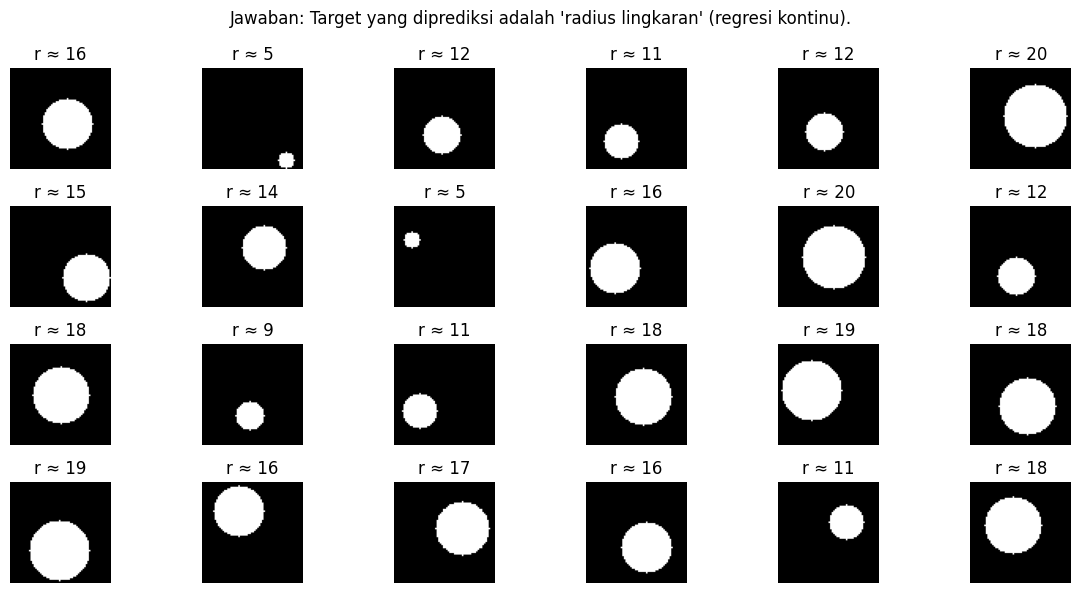

In [9]:
# Tampilkan kembali, sekarang tampilkan radius (label) di judul tiap subplot
plt.figure(figsize=(12, 6))

for i in range(N_show):
    # All lines inside the loop start with 4 spaces
    plt.subplot(rows, cols, i+1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.title(f"r ≈ {int(rads[i])}")
    plt.axis('off')

plt.suptitle("Jawaban: Target yang diprediksi adalah 'radius lingkaran' (regresi kontinu).")
plt.tight_layout()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
MAE=0.967 | RMSE=1.184 | R²=0.934


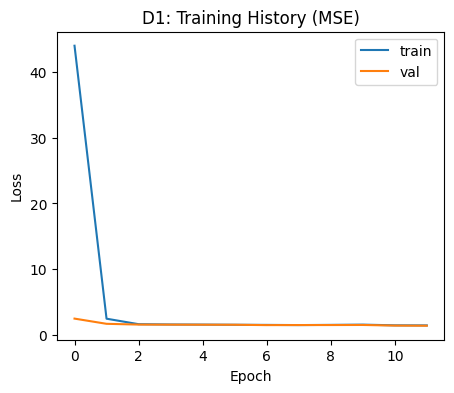

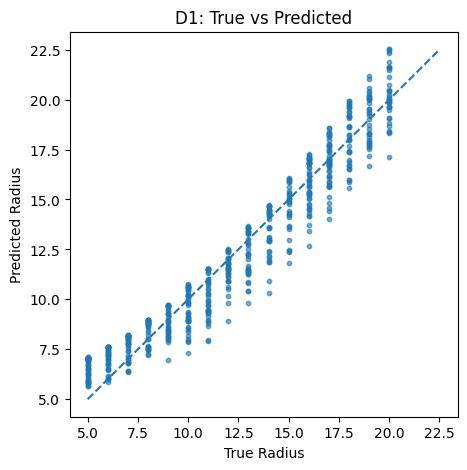

In [32]:
# Siapkan dataset lebih besar untuk training
N = 3000
X, y, C = zip(*[make_sample() for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# Model CNN sederhana
model = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)  # output regresi
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(Xtr, ytr, validation_data=(Xte, yte),
                      epochs=12, batch_size=64, verbose=0)

# Evaluasi
y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = float(np.sqrt(np.mean((yte - y_pred)**2)))
r2 = r2_score(yte, y_pred)
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

# Plot loss
plt.figure(figsize=(5, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("D1: Training History (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

# Scatter True vs Pred
plt.figure(figsize=(5, 5))
plt.scatter(yte, y_pred, s=10, alpha=0.6)
lims = [min(yte.min(), y_pred.min()), max(yte.max(), y_pred.max())]
plt.plot(lims, lims, '--')
plt.xlabel("True Radius"); plt.ylabel("Predicted Radius")
plt.title("D1: True vs Predicted")
plt.show()

### Tantangan Mini

In [33]:
# Fungsi generator dengan rentang radius baru
def make_sample_new_radius(img_size=64, min_r=8, max_r=28):
    # Radius sekarang antara 8 dan 28
    r = np.random.randint(min_r, max_r + 1)
    img = np.zeros((img_size, img_size), dtype=np.uint8)

    # Pastikan pusat lingkaran tidak membuat lingkaran terpotong
    cx = np.random.randint(r, img_size - r)
    cy = np.random.randint(r, img_size - r)

    cv2.circle(img, (cx, cy), r, (255,), -1)
    img = (img / 255.0).astype(np.float32)
    img3 = np.stack([img, img, img], axis=-1)
    return img3, float(r), (cx, cy)

# --- Ulangi proses training dengan data baru ---

# 1. Buat dataset baru
N = 3000
X_new, y_new, _ = zip(*[make_sample_new_radius() for _ in range(N)])
X_new = np.array(X_new, dtype=np.float32)
y_new = np.array(y_new, dtype=np.float32)

# 2. Split data
Xtr_new, Xte_new, ytr_new, yte_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# 3. Latih ulang model (gunakan arsitektur model yang sama)
print("Melatih model dengan rentang radius 8-28...")
history_new = model.fit(Xtr_new, ytr_new, validation_data=(Xte_new, yte_new),
                        epochs=12, batch_size=64, verbose=0)

# 4. Evaluasi
y_pred_new = model.predict(Xte_new).ravel()
mae_new = mean_absolute_error(yte_new, y_pred_new)
rmse_new = float(np.sqrt(np.mean((yte_new - y_pred_new)**2)))
r2_new = r2_score(yte_new, y_pred_new)

print(f"Hasil Radius Baru (8-28): MAE={mae_new:.3f} | RMSE={rmse_new:.3f} | R²={r2_new:.3f}")

Melatih model dengan rentang radius 8-28...
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Hasil Radius Baru (8-28): MAE=0.795 | RMSE=0.975 | R²=0.974


In [34]:
# Fungsi generator dengan tambahan Gaussian blur
def make_sample_noisy(img_size=64, min_r=5, max_r=20):
    r = np.random.randint(min_r, max_r + 1)
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    cx = np.random.randint(r, img_size - r)
    cy = np.random.randint(r, img_size - r)
    cv2.circle(img, (cx, cy), r, (255,), -1)

    # --- TAMBAHKAN NOISE DI SINI ---
    # Tambahkan blur; (5,5) adalah ukuran kernel blur
    img = cv2.GaussianBlur(img, (5, 5), 0)
    #

    img = (img / 255.0).astype(np.float32)
    img3 = np.stack([img, img, img], axis=-1)
    return img3, float(r), (cx, cy)

# --- Ulangi proses training dengan data yang di-blur ---

# 1. Buat dataset baru yang noisy
X_noisy, y_noisy, _ = zip(*[make_sample_noisy() for _ in range(N)])
X_noisy = np.array(X_noisy, dtype=np.float32)
y_noisy = np.array(y_noisy, dtype=np.float32)

# 2. Split data
Xtr_noisy, Xte_noisy, ytr_noisy, yte_noisy = train_test_split(X_noisy, y_noisy, test_size=0.2, random_state=42)

# 3. Latih ulang model
print("\nMelatih model dengan citra yang di-blur...")
history_noisy = model.fit(Xtr_noisy, ytr_noisy, validation_data=(Xte_noisy, yte_noisy),
                          epochs=12, batch_size=64, verbose=0)

# 4. Evaluasi
y_pred_noisy = model.predict(Xte_noisy).ravel()
mae_noisy = mean_absolute_error(yte_noisy, y_pred_noisy)
rmse_noisy = float(np.sqrt(np.mean((yte_noisy - y_pred_noisy)**2)))
r2_noisy = r2_score(yte_noisy, y_pred_noisy)

print(f"Hasil Citra Noisy: MAE={mae_noisy:.3f} | RMSE={rmse_noisy:.3f} | R²={r2_noisy:.3f}")


Melatih model dengan citra yang di-blur...
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Hasil Citra Noisy: MAE=0.942 | RMSE=1.194 | R²=0.937


In [35]:
# 1. Siapkan data dengan target [r, cx, cy]
N = 3000
samples_multi = [make_sample() for _ in range(N)]
X_multi = np.array([s[0] for s in samples_multi], dtype=np.float32)

# Target 'y' sekarang adalah array (N, 3)
y_multi = np.array([[s[1], s[2][0], s[2][1]] for s in samples_multi], dtype=np.float32)

# 2. Split data
Xtr_multi, Xte_multi, ytr_multi, yte_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# 3. Ubah arsitektur model
# Lapisan output harus memiliki 3 neuron, bukan 1
model_multi = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'), layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    # --- UBAH LAPISAN INI ---
    layers.Dense(3)  # Output: [radius, center_x, center_y]
])

# 4. Compile dan latih
# Loss 'mse' bekerja dengan baik untuk multi-output regression
model_multi.compile(optimizer='adam', loss='mse')

print("\nMelatih model multi-output...")
model_multi.fit(Xtr_multi, ytr_multi, validation_data=(Xte_multi, yte_multi),
                epochs=12, batch_size=64, verbose=0)

# 5. Evaluasi (lihat bagian metrik di bawah)
y_pred_multi = model_multi.predict(Xte_multi)


Melatih model multi-output...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [36]:
# Pisahkan nilai asli dan prediksi
r_true, cx_true, cy_true = yte_multi[:, 0], yte_multi[:, 1], yte_multi[:, 2]
r_pred, cx_pred, cy_pred = y_pred_multi[:, 0], y_pred_multi[:, 1], y_pred_multi[:, 2]

# Hitung MAE untuk setiap komponen
mae_r = mean_absolute_error(r_true, r_pred)
mae_cx = mean_absolute_error(cx_true, cx_pred)
mae_cy = mean_absolute_error(cy_true, cy_pred)

print(f"MAE Radius: {mae_r:.3f}")
print(f"MAE Center-X: {mae_cx:.3f}")
print(f"MAE Center-Y: {mae_cy:.3f}")
dist_error = np.sqrt((cx_true - cx_pred)**2 + (cy_true - cy_pred)**2)
print(f"Rata-rata error jarak pusat: {np.mean(dist_error):.3f} piksel")

MAE Radius: 1.165
MAE Center-X: 4.898
MAE Center-Y: 5.337
Rata-rata error jarak pusat: 7.763 piksel


## Praktikum D2 – Menebak Umur Manusia dari Foto Wajah (UTKFace)

In [21]:
# Jalankan ini di awal notebook
from google.colab import files
files.upload()  # pilih file kaggle.json dari komputer Anda

Saving kaggle.json to kaggle (3).json


{'kaggle (3).json': b'{"username":"rayegans","key":"24f9c5fb34eeb81b9e6f502510310246"}'}

In [22]:
import os
import shutil

# Periksa apakah file kaggle.json ada
if os.path.exists("kaggle.json"):
    # Buat folder .kaggle jika belum ada
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

    # Salin file API key ke folder .kaggle
    shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))

    # Atur izin file agar aman (hanya bisa dibaca oleh pemilik)
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

    # Install library Kaggle (perintah ini untuk environment seperti Colab/Jupyter)
    !pip -q install kaggle

    print("✅ Kaggle API siap digunakan.")
else:
    # Beri pesan jika file tidak ditemukan
    print("❌ kaggle.json belum ditemukan. Silakan upload terlebih dahulu.")

✅ Kaggle API siap digunakan.


In [ ]:
# Unduh dataset UTKFace (sekali saja)
!kaggle datasets download -d jangedoo/utkface-new -p /content -q

# Ekstrak file zip
!unzip -q /content/utkface-new.zip -d /content/utk

# Tampilkan pesan setelah selesai
print("✅ Dataset UTKFace berhasil diekstrak.")


Total gambar ditemukan: 23708


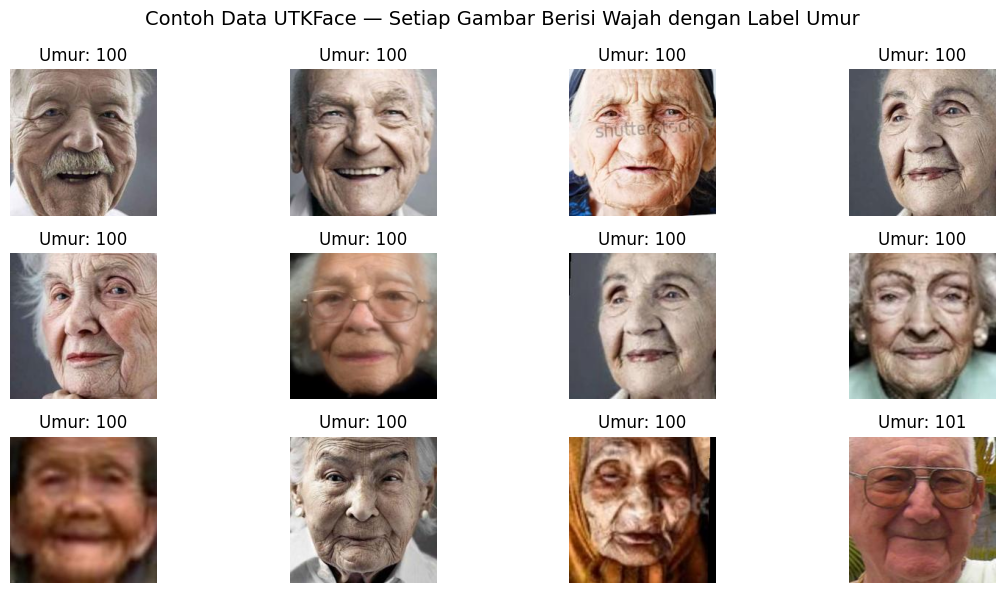

In [23]:
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image

# Ambil 12 gambar acak dari dataset
# Ganti path ini jika lokasi file Anda berbeda
files = glob.glob("/content/utk/UTKFace/*.jpg")
files = sorted(files)
print(f"Total gambar ditemukan: {len(files)}")

plt.figure(figsize=(12, 6))

# Loop untuk menampilkan 12 gambar pertama
for i, f in enumerate(files[:12]):
    # Ambil umur dari nama file
    age = int(os.path.basename(f).split("_")[0])
    img = Image.open(f)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Umur: {age}")
    plt.axis("off")

plt.suptitle("Contoh Data UTKFace — Setiap Gambar Berisi Wajah dengan Label Umur", fontsize=14)
plt.tight_layout()
plt.show() # Perintah ini ditambahkan untuk menampilkan plot

In [37]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

def parse_age_from_name(fp):
  return int(os.path.basename(fp).split('_')[0])

ages = np.array([parse_age_from_name(f) for f in files], dtype=np.float32)
train_files, test_files, y_train, y_test = train_test_split(
    files, ages, test_size=0.2, random_state=42
)

IMG_SIZE = 160
def load_img(fp, label):
  img = tf.io.read_file(fp)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
  return img / 255.0, label

train_ds = tf.data.Dataset.from_tensor_slices((train_files, y_train)).map(load_img).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((test_files, y_test)).map(load_img).batch(64)

print("✅ Dataset siap dilatih.")

✅ Dataset siap dilatih.


In [38]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Gunakan GPU jika tersedia
print("Hardware:", "GPU" if tf.config.list_physical_devices('GPU') else "CPU")

# Buat arsitektur model
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base_model.trainable = False # tahap awal: freeze backbone

# Tambahkan head regresi
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1)(x) # output tunggal: umur
model = tf.keras.Model(inputs, outputs)

# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss='mse', metrics=['mae'])

model.summary()

Hardware: GPU


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_1 (Multiply)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 39s 85ms/step - loss: 325.6049 - mae: 13.2720 - val_loss: 158.1490 - val_mae: 9.5843 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - loss: 152.2311 - mae: 9.1602 - val_loss: 146.7525 - val_mae: 9.1180 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - loss: 144.3281 - mae: 8.8316 - val_loss: 141.8232 - val_mae: 8.9013 - learning_rate: 0.0010
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - loss: 140.2748 - mae: 8.7176 - val_loss: 139.1247 - val_mae: 8.7640 - learning_rate: 0.0010
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - loss: 137.8897 - mae: 8.5758 - val_loss: 139.6595 - val_mae: 8.7845 - learning_rate: 0.0010
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - loss: 135.5788 - mae: 8.5002 - val_loss: 136.5301 - val_mae: 8.6268 - learning_rate: 0.0010
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - loss: 134.3167 - mae: 8.4791 - val_loss: 134.6938 - val

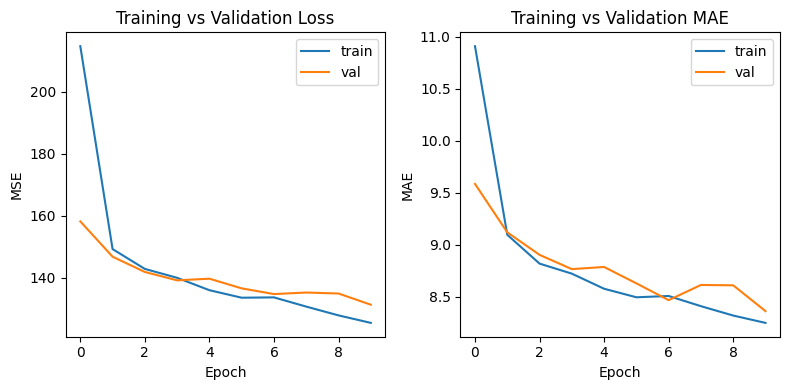

In [39]:
# Callback untuk pelatihan yang lebih stabil
cb = [
  tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
  tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-5, monitor='val_loss')
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=cb,
    verbose=1
)

# Visualisasi perubahan loss dan MAE selama pelatihan:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.tight_layout()
plt.show()

Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 49s 110ms/step - loss: 28.4376 - mae: 4.0141 - val_loss: 100.2708 - val_mae: 7.1745 - learning_rate: 1.0000e-04
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - loss: 29.3516 - mae: 3.9379 - val_loss: 114.5507 - val_mae: 7.9520 - learning_rate: 1.0000e-04
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - loss: 22.5327 - mae: 3.5165 - val_loss: 106.9796 - val_mae: 7.4445 - learning_rate: 1.0000e-04
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 19.5876 - mae: 3.2797 - val_loss: 91.5063 - val_mae: 6.8584 - learning_rate: 5.0000e-05
Epoch 5/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - loss: 14.4436 - mae: 2.8557 - val_loss: 90.6803 - val_mae: 6.8529 - learning_rate: 5.0000e-05


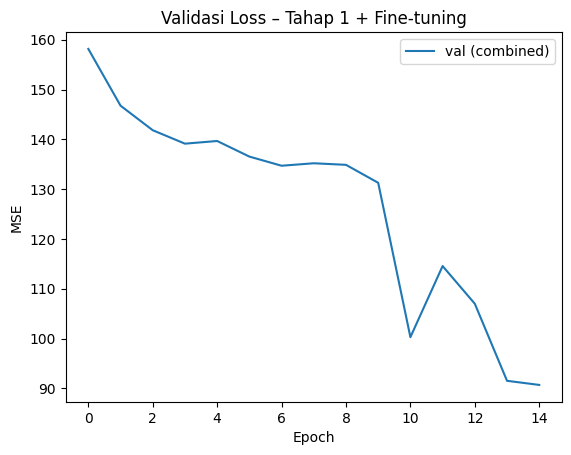

In [51]:
# Aktifkan kembali sebagian layer terakhir untuk fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
  layer.trainable = False # beku sebagian besar layer

# Recompile dengan learning rate lebih kecil
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                loss='mse', metrics=['mae'])

history_ft = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=cb,
    verbose=1
)

# Visualisasi gabungan training dan fine-tuning:
plt.plot(history.history['val_loss'] + history_ft.history['val_loss'], label='val (combined)')
plt.title("Validasi Loss – Tahap 1 + Fine-tuning")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.show()

MAE = 7.26 tahun
RMSE = 9.98 tahun
R²	= 0.749


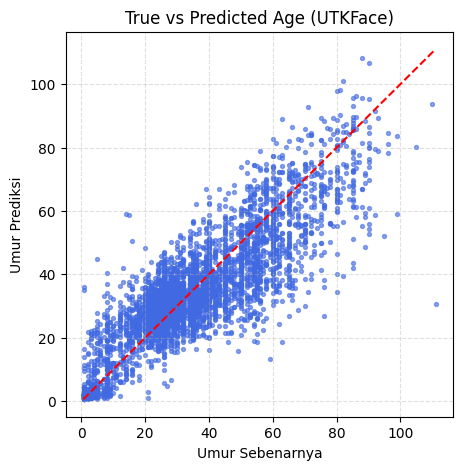

In [42]:
from math import sqrt

y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for batch in test_ds])
mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(np.mean((y_test - y_pred)**2))
r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.2f} tahun")
print(f"RMSE = {rmse:.2f} tahun")
print(f"R²	= {r2:.3f}")

# Plot “umur sebenarnya vs umur prediksi”:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=8, alpha=0.6, color='royalblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("Umur Sebenarnya")
plt.ylabel("Umur Prediksi")
plt.title("True vs Predicted Age (UTKFace)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

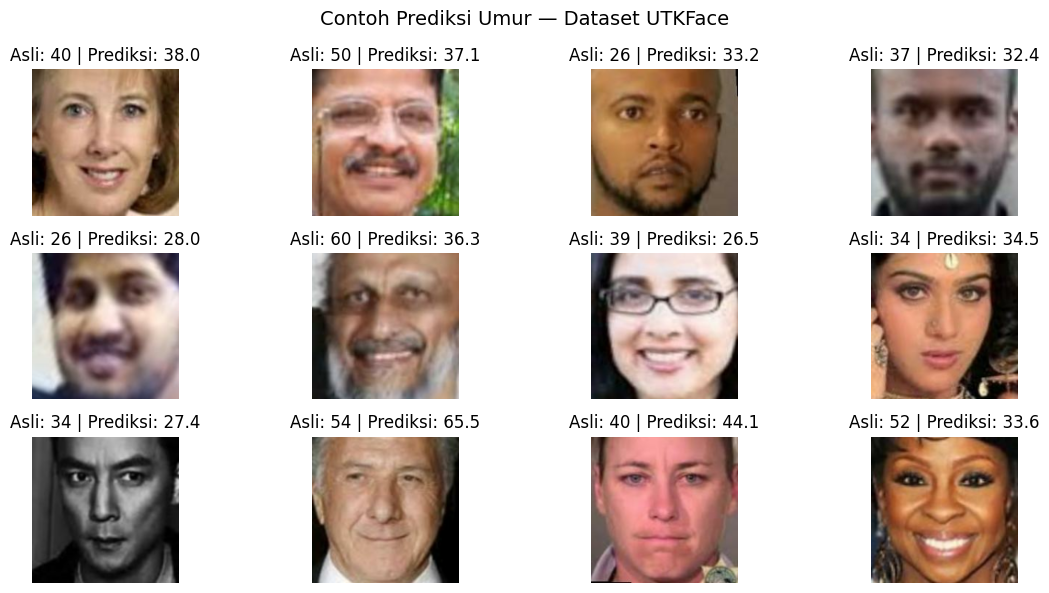

In [43]:
import random
import tensorflow as tf # Pastikan tf diimpor
import os # Pastikan os diimpor

# Ambil 12 sampel acak dari file tes
sample_paths = random.sample(list(test_files), 12)

plt.figure(figsize=(12, 6))

for i, path in enumerate(sample_paths):
    # Muat dan proses gambar
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    # Ambil umur asli dari nama file
    true_age = int(os.path.basename(path).split('_')[0])

    # Lakukan prediksi umur
    pred_age = model.predict(tf.expand_dims(img, 0), verbose=0).ravel()[0]

    # Tampilkan gambar dan hasil
    plt.subplot(3, 4, i + 1)
    plt.imshow(img.numpy())
    plt.title(f"Asli: {true_age} | Prediksi: {pred_age:.1f}")
    plt.axis('off')

plt.suptitle("Contoh Prediksi Umur — Dataset UTKFace", fontsize=14)
plt.tight_layout()
plt.show()

## Praktikum D3 — Menilai “Kepopuleran Hewan Peliharaan” dari Foto

In [11]:
from google.colab import files
import os
import shutil

# Minta pengguna untuk mengunggah file kaggle.json
files.upload()

# Periksa apakah file berhasil diunggah sebelum melanjutkanya
if os.path.exists("kaggle.json"):
    # Buat direktori .kaggle jika belum ada
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

    # Salin file API key ke direktori yang benar
    shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))

    # Atur izin file agar aman (hanya bisa dibaca oleh pemilik)
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

    # Install library Kaggle
    !pip -q install kaggle

    print("✅ Kaggle API siap digunakan.")
else:
    print("❌ kaggle.json tidak ditemukan setelah proses upload.")

Saving kaggle.json to kaggle (2).json
✅ Kaggle API siap digunakan.


In [12]:
# Unduh dataset Pawpularity (sekitar 800MB)
!kaggle competitions download -c petfinder-pawpularity-score -p /content -q

# Ekstrak file zip ke folder 'paw'
!unzip -q /content/petfinder-pawpularity-score.zip -d /content/paw

# Tampilkan pesan konfirmasi
print("✅ Dataset Pawpularity berhasil diekstrak.")

User cancelled operation
replace /content/paw/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ✅ Dataset Pawpularity berhasil diekstrak.


                                 Id  Subject Focus  Eyes  Face  Near  Action  \
0  0007de18844b0dbbb5e1f607da0606e0              0     1     1     1       0   
1  0009c66b9439883ba2750fb825e1d7db              0     1     1     0       0   
2  0013fd999caf9a3efe1352ca1b0d937e              0     1     1     1       0   
3  0018df346ac9c1d8413cfcc888ca8246              0     1     1     1       0   
4  001dc955e10590d3ca4673f034feeef2              0     0     0     1       0   

   Accessory  Group  Collage  Human  Occlusion  Info  Blur  Pawpularity  \
0          0      1        0      0          0     0     0           63   
1          0      0        0      0          0     0     0           42   
2          0      0        0      1          1     0     0           28   
3          0      0        0      0          0     0     0           15   
4          0      1        0      0          0     0     0           72   

                                                path  
0  /content/p

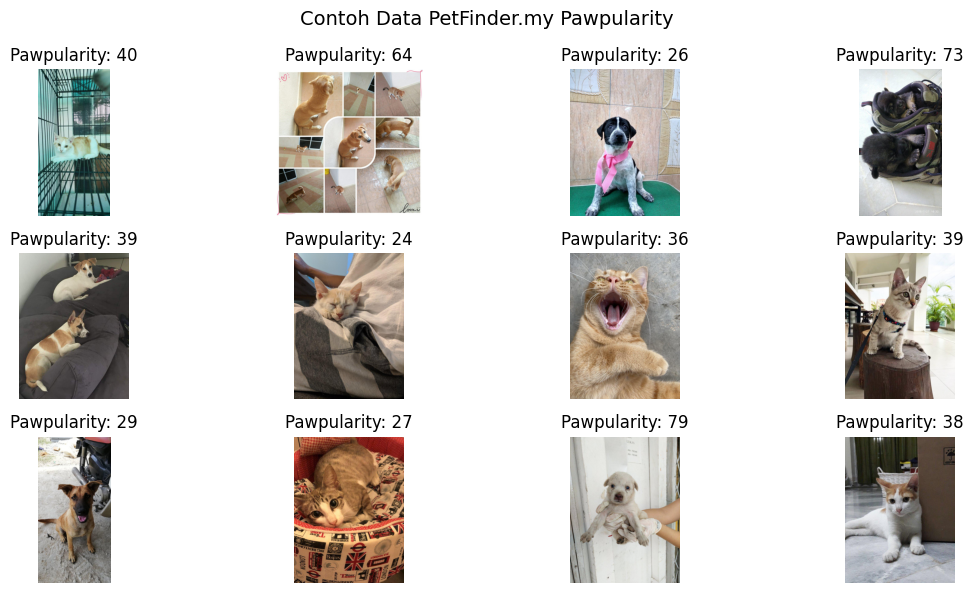

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

# Muat file CSV
df = pd.read_csv('/content/paw/train.csv')

# Buat kolom 'path' untuk lokasi file gambar
df['path'] = df['Id'].apply(lambda x: f"/content/paw/train/{x}.jpg")
print(df.head())

# Tampilkan 12 contoh gambar acak
plt.figure(figsize=(12, 6))
for i, row in enumerate(df.sample(12, random_state=42).itertuples()):
    img = Image.open(row.path)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Pawpularity: {row.Pawpularity}")
    plt.axis('off')

plt.suptitle("Contoh Data PetFinder.my Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Pastikan variabel 'df' sudah didefinisikan dari blok kode sebelumnya
IMG_SIZE = 224
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)

# Membuat pipeline dataset training
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['Pawpularity']))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(4096)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

# Membuat pipeline dataset validasi
val_ds = (
    tf.data.Dataset.from_tensor_slices((val_df['path'], val_df['Pawpularity']))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Dataset siap digunakan — {len(train_df)} untuk training, {len(val_df)} untuk validasi.")

Dataset siap digunakan — 7929 untuk training, 1983 untuk validasi.


In [15]:
from tensorflow.keras import layers, models

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base.trainable = False  # freeze sementara

inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs * 255.0)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
# Callback untuk menghentikan training jika tidak ada kemajuan dan mengurangi learning rate
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]

# Latih model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=cb,
    verbose=1
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 111s 510ms/step - loss: 865.1773 - mae: 22.0774 - val_loss: 487.7654 - val_mae: 16.4774 - learning_rate: 0.0010
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 199ms/step - loss: 435.0860 - mae: 15.4309 - val_loss: 438.3360 - val_mae: 15.1639 - learning_rate: 0.0010
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 45s 231ms/step - loss: 397.1003 - mae: 14.6399 - val_loss: 408.6991 - val_mae: 14.7312 - learning_rate: 0.0010
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 198ms/step - loss: 372.9360 - mae: 14.2264 - val_loss: 393.1051 - val_mae: 14.7774 - learning_rate: 0.0010
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 197ms/step - loss: 361.0413 - mae: 14.1473 - val_loss: 380.9184 - val_mae: 14.3856 - learning_rate: 0.0010
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 205ms/step - loss: 339.6933 - mae: 13.6731 - val_loss: 373.6386 - val_mae: 14.1969 - learning_rate: 0.0010
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 237ms/step - loss: 338.2293 - mae: 13.6554 - val_

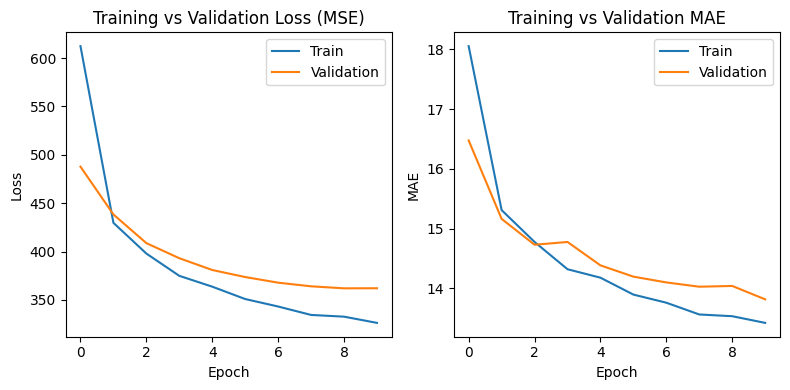

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Training vs Validation Loss (MSE)")
plt.xlabel("Epoch");
plt.ylabel("Loss");
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Validation')
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch");
plt.ylabel("MAE");
plt.legend()
plt.tight_layout()
plt.show()


MAE  = 14.04
RMSE = 19.03
R²   = 0.181


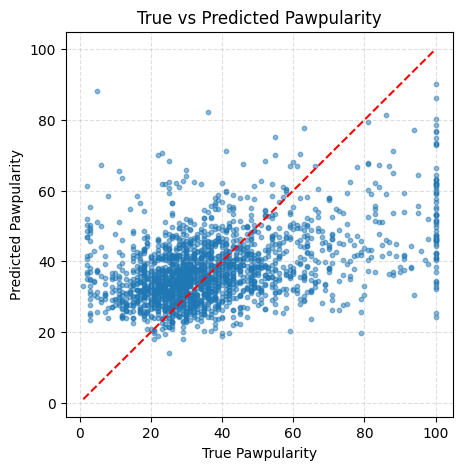

In [19]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt
import matplotlib.pyplot as plt # Library ini perlu di-import

# Ambil nilai Pawpularity asli dari dataframe validasi
y_true = val_df['Pawpularity'].values.astype(np.float32)

# Lakukan prediksi pada seluruh data validasi
y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for batch in val_ds])

# Hitung metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
rmse = sqrt(np.mean((y_true - y_pred)**2))
r2 = r2_score(y_true, y_pred)

print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")

# Plot hasil prediksi vs nilai sebenarnya:
plt.figure(figsize=(5, 5))
plt.scatter(y_true, y_pred, s=10, alpha=0.5)

# Buat garis diagonal sebagai referensi prediksi sempurna
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')

plt.xlabel("True Pawpularity")
plt.ylabel("Predicted Pawpularity")
plt.title("True vs Predicted Pawpularity")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

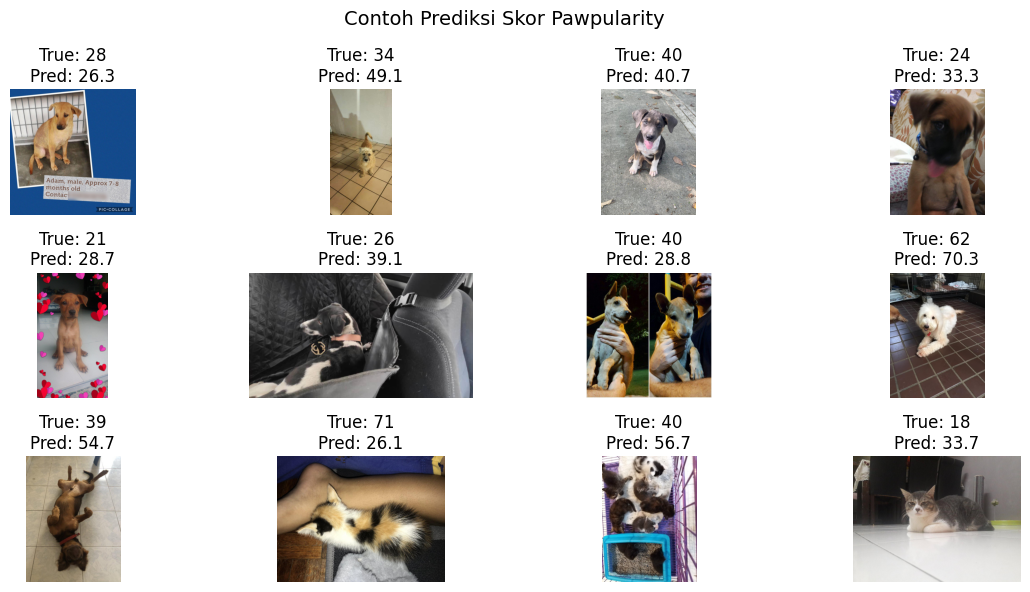

In [20]:
import random
from PIL import Image
import tensorflow as tf # Library ini perlu di-import
import matplotlib.pyplot as plt # Library ini perlu di-import

# Ambil 12 sampel acak dari dataframe validasi
sample_rows = val_df.sample(12, random_state=1)

plt.figure(figsize=(12, 6))
for i, row in enumerate(sample_rows.itertuples()):
    # Buka gambar asli untuk ditampilkan
    img = Image.open(row.path)

    # Muat dan proses gambar untuk prediksi, lalu lakukan prediksi
    processed_img, _ = load_image(row.path, row.Pawpularity)
    pred = model.predict(tf.expand_dims(processed_img, 0), verbose=0).ravel()[0]

    # Tampilkan gambar dan hasil
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"True: {row.Pawpularity}\nPred: {pred:.1f}")
    plt.axis('off')

plt.suptitle("Contoh Prediksi Skor Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

# Penugasan
## 3.	Gunakan foto pribadi untuk menampilkan ujicoba prediksi usia kalian — tampilkan hasilnya di laporan!

Upload satu atau beberapa gambar wajah (.jpg / .png)


Saving tes.jpg to tes.jpg
Gambar 'tes.jpg' → Prediksi umur: 7.5 tahun


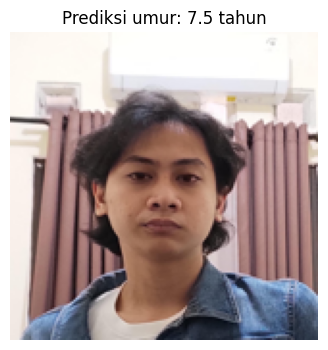

In [52]:
# === Uji model pada wajah sendiri (upload gambar), resize, dan prediksi ===

from google.colab import files
import tensorflow as tf
import numpy as np
from PIL import Image
import io, os
import matplotlib.pyplot as plt

# --- Konfigurasi sesuai training ---
IMG_SIZE = 160       # sama seperti saat kamu training
LABEL_SCALE = 1.0    # ubah ke 100.0 kalau kamu pernah membagi umur saat training (age/100)

# --- Pastikan model sudah ada ---
if "model" not in globals():
    raise RuntimeError("Model belum ada di memori. Jalankan dulu sel pelatihan yang membuat variabel 'model'.")

# --- Upload gambar ---
print("Upload satu atau beberapa gambar wajah (.jpg / .png)")
uploaded = files.upload()

if len(uploaded) == 0:
    print("❌ Tidak ada file yang diupload.")
else:
    for fname, filebytes in uploaded.items():
        # Baca dan ubah ke RGB
        img = Image.open(io.BytesIO(filebytes)).convert("RGB")

        # Resize ke ukuran input model
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))

        # Normalisasi sesuai dataset training (kamu pakai img/255.0)
        img_arr = np.array(img_resized).astype(np.float32) / 255.0
        input_tensor = tf.expand_dims(img_arr, 0)  # tambahkan dimensi batch

        # Prediksi umur
        pred_age = model.predict(input_tensor, verbose=0).ravel()[0] * LABEL_SCALE

        # Tampilkan hasil
        print(f"Gambar '{fname}' → Prediksi umur: {pred_age:.1f} tahun")

        plt.figure(figsize=(4,4))
        plt.imshow(img_resized)
        plt.title(f"Prediksi umur: {pred_age:.1f} tahun")
        plt.axis("off")
        plt.show()


## 4.	gunakan foto pribadi (atau hewan peliharaan sendiri) dan uji model Pawpularity — tampilkan hasilnya di laporan!

Upload 1 gambar hewan peliharaan (jpg/png). Setelah upload, sel akan memproses dan menampilkan prediksi Pawpularity.


Saving WhatsApp Image 2025-10-18 at 17.35.34_0ee58853.jpg to WhatsApp Image 2025-10-18 at 17.35.34_0ee58853.jpg


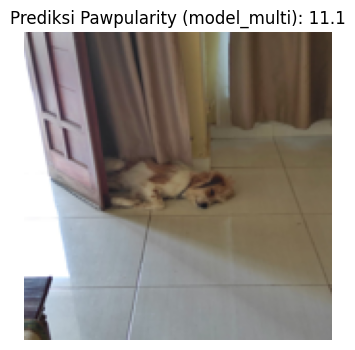

Model yang dipakai: model_multi
Prediksi Pawpularity: 11.1 (skor 0-100)


In [53]:

# === Uji Prediksi Pawpularity dengan Foto Hewan Peliharaan
from google.colab import files
import tensorflow as tf
import numpy as np
from PIL import Image
import io, os
import matplotlib.pyplot as plt

print("Upload 1 gambar hewan peliharaan (jpg/png). Setelah upload, sel akan memproses dan menampilkan prediksi Pawpularity.")
uploaded = files.upload()

if len(uploaded) == 0:
    print("Tidak ada file yang diupload. Jalankan ulang sel dan pilih file.")
else:
    fname = list(uploaded.keys())[0]
    img = Image.open(io.BytesIO(uploaded[fname])).convert('RGB')

    try:
        IMG_SIZE
    except NameError:
        IMG_SIZE = 224

    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    img_arr = np.array(img_resized).astype(np.float32) / 255.0
    inp = tf.expand_dims(img_arr, 0)

    # Pilih model regresi Pawpularity: best_reg_model, model_e3, model_r50, model_nv, model_multi, atau model (checkpoint sebelumnya)
    model_candidates = ['best_reg_model','model_e3','model_r50','model_nv','model_multi','model','model_aug']
    paw_model = None
    chosen_name = None
    for name in model_candidates:
        if name in globals() and globals()[name] is not None:
            paw_model = globals()[name]
            chosen_name = name
            break

    if paw_model is None:
        print("Tidak menemukan model Pawpularity terlatih di runtime. Jalankan sel pelatihan Pawpularity (mis. sel D3 di sebelumnya).")
    else:
        # beberapa model menerima multi-input (image + brightness)
        try:
            # detect if model expects two inputs by checking input shape or input count
            if isinstance(paw_model.input, list) and len(paw_model.input) == 2:
                # compute brightness scalar
                gray = tf.image.rgb_to_grayscale(img_arr)
                bright = float(tf.reduce_mean(gray).numpy())
                pred = paw_model.predict([inp, np.array([bright])], verbose=0).ravel()[0]
            else:
                # standard single-input
                # try using efficientnet/resnet preprocess if needed based on model name
                if 'efficientnet' in chosen_name or 'e3' in chosen_name:
                    x_in = tf.keras.applications.efficientnet.preprocess_input(inp * 255.0)
                elif 'resnet' in chosen_name:
                    x_in = tf.keras.applications.resnet.preprocess_input(inp * 255.0)
                else:
                    x_in = inp
                pred = paw_model.predict(x_in, verbose=0).ravel()[0]
        except Exception:
            # fallback raw predict
            pred = paw_model.predict(inp, verbose=0).ravel()[0]

        plt.figure(figsize=(6,4))
        plt.imshow(img_resized)
        plt.axis('off')
        plt.title(f"Prediksi Pawpularity ({chosen_name}): {pred:.1f}")
        plt.show()

        print(f"Model yang dipakai: {chosen_name}")
        print(f"Prediksi Pawpularity: {pred:.1f} (skor 0-100)")
